# Chronic Urticaria – Baseline Ablation Models
## Lab-Only vs Clinical-Text-Only (Comparison against Gated Fusion MTL)

**Purpose**: Train two ablation baselines on `final_3000_Risk_Dataset.csv` with the
**identical** targets, preprocessing, losses, and evaluation protocol as the main
`ClinicalSafe_CU_MTL_Improved_(2)` notebook. The gap between these baselines and the
Gated Fusion model quantifies the contribution of each modality.

| Model | Inputs | Architecture |
|---|---|---|
| **Lab-Only (Tabular)** | CRP, FT4, IgE, VitD, Age, Weight, Height + questionnaire OHE | Deep MLP, 3-layer residual |
| **Text-Only (ClinicalBERT)** | `symptoms_raw` + `investigations_raw` (BERT tokenised) | BioClinicalBERT + Attention Pooling |
| **Gated Fusion (main model)** | Both modalities fused via per-task gate | BioClinicalBERT + Residual MLP + Gate |

All models are **multi-task**: urticaria type (3-class) · secondary disease risk (multi-label)
· side-effect proxy (3-class) · severity regression (itching score).

## 0) Install & Imports

In [1]:
# Install required packages (comment out if already installed)
!pip -q install transformers accelerate scikit-learn pandas numpy tqdm joblib

import os, json, math, random
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import classification_report, f1_score, roc_auc_score, accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.model_selection import train_test_split
import joblib

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 1) Load Dataset

In [2]:
# ── Adjust path if needed ─────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
CSV_PATH = "/content/drive/MyDrive/AURA/final_3000_dataset/final_3000_Risk_Dataset.csv"  # <-- change this
print("Using:", CSV_PATH)

df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(2)

Mounted at /content/drive
Using: /content/drive/MyDrive/AURA/final_3000_dataset/final_3000_Risk_Dataset.csv
Shape: (3000, 39)
Columns: ['split', 'symptoms_raw', 'investigations_raw', 'CRP', 'FT4', 'IgE', 'VitD', 'Age', 'History of Chronic Urticaria', 'Sex', 'Weight', 'Height', 'Symptoms Of Urticaria', 'Diagnosed at the age of', 'Duration of Symptoms of urticaria', 'If Wheals are present', 'The shape of an individual wheal', 'Size of a single Wheal', 'No. of wheals', 'Duration of wheal', 'Itching score', 'Location', 'If  angioedema is present', 'Duration of angioedema', 'Discomfort of Swelling', 'Affect of Swelling on Daily activities', 'Angioedema affect on appearance', 'Overall affect of Swelling', 'Remission of Angioedema after discontinuation of the drug:', 'Which applies to your wheals/angioedema or both?', 'Which of the following applies to your symptoms of urticaria?', 'Which time of the day do the symptoms occur?', 'Symptoms of Autoinflamation:', 'Specify other allergy', 'Alpha 

,split,symptoms_raw,investigations_raw,CRP,FT4,IgE,VitD,Age,History of Chronic Urticaria,Sex,...,Which applies to your wheals/angioedema or both?,Which of the following applies to your symptoms of urticaria?,Which time of the day do the symptoms occur?,Symptoms of Autoinflamation:,Specify other allergy,Alpha Gal,Family History of Urticaria,Family history of thyroid diseases,Family history of autoimmune diseases,urticaria_type
0,train,"Recurrent urticaria, itching","CBC, CRP, FT4, IgE, Vitamin D",8.73,1.48,114.41,25.75,59,No,Female,...,Can induce through specific stimuli,Itching,No Significance,Recurrent unexplained Fever,Hair dye,Positive,Yes,Yes,Yes,Inducible
1,validation,"Itching, Wheals, Swelling","CBC, CRP, FT4, IgE, Vitamin D",10.67,1.40,204.41,38.58,43,No,Female,...,Can induce through specific stimuli,Itching,No Significance,Recurrent unexplained Fever,Prawn like food allergy,Not tested,No,No,No,Inducible


## 2) Define Column Sets (identical to main notebook)

In [3]:
# ── Text columns (used by Text-Only model only) ───────────────────────────────
TEXT_COLS = ["symptoms_raw", "investigations_raw"]

# ── Numeric lab / demographic features (used by Lab-Only model) ──────────────
LAB_COLS = ["CRP", "FT4", "IgE", "VitD", "Age", "Weight", "Height",
            "Diagnosed at the age of"]

# ── Family history (categorical) ─────────────────────────────────────────────
FAM_COLS = [
    "Family History of Urticaria",
    "Family history of thyroid diseases",
    "Family history of autoimmune diseases",
]

# ── Structured symptom questionnaire (categorical) ────────────────────────────
SYM_COLS = [
    "Sex", "History of Chronic Urticaria", "Symptoms Of Urticaria",
    "Duration of Symptoms of urticaria", "If Wheals are present",
    "The shape of an individual wheal", "Size of a single Wheal",
    "No. of wheals", "Duration of wheal", "Location",
    "If  angioedema is present", "Duration of angioedema",
    "Discomfort of Swelling", "Affect of Swelling on Daily activities",
    "Angioedema affect on appearance", "Overall affect of Swelling",
    "Which applies to your wheals/angioedema or both?",
    "Which of the following applies to your symptoms of urticaria?",
    "Which time of the day do the symptoms occur?",
    "Symptoms of Autoinflamation:", "Alpha Gal", "Specify other allergy",
    "Remission of Angioedema after discontinuation of the drug:",
]

TARGET_TYPE = "urticaria_type"

def keep_existing(lst):
    return [c for c in lst if c in df.columns]

TEXT_COLS = keep_existing(TEXT_COLS)
LAB_COLS  = keep_existing(LAB_COLS)
FAM_COLS  = keep_existing(FAM_COLS)
SYM_COLS  = keep_existing(SYM_COLS)

NUM_COLS = LAB_COLS
CAT_COLS = FAM_COLS + SYM_COLS

print("NUM_COLS:", NUM_COLS)
print("CAT_COLS count:", len(CAT_COLS))
print("TEXT_COLS:", TEXT_COLS)

NUM_COLS: ['CRP', 'FT4', 'IgE', 'VitD', 'Age', 'Weight', 'Height', 'Diagnosed at the age of']
CAT_COLS count: 26
TEXT_COLS: ['symptoms_raw', 'investigations_raw']


## 3) Build Target Labels (identical proxy logic as main notebook)

In [4]:
# ── Urticaria type ────────────────────────────────────────────────────────────
type_classes = sorted(df[TARGET_TYPE].dropna().unique().tolist())
type2id = {c: i for i, c in enumerate(type_classes)}
id2type  = {i: c for c, i in type2id.items()}
print("Urticaria types:", type_classes)

def yn_to_int(x):
    if pd.isna(x): return 0
    return 1 if str(x).strip().lower() in ["yes", "y", "true", "1"] else 0

# ── Thyroid risk proxy (score ≥ 3 → positive) ────────────────────────────────
_ige_med = df["IgE"].median()
_ige_q75 = df["IgE"].quantile(0.75)
_crp_q75 = df["CRP"].quantile(0.75)
_ft4_lo  = df["FT4"].quantile(0.10)
_ft4_hi  = df["FT4"].quantile(0.90)
_vitd_lo = df["VitD"].quantile(0.25)
_ft4_mid = (_ft4_lo + _ft4_hi) / 2

def _make_thyroid_risk(row):
    s = 0
    if yn_to_int(row.get("Family history of thyroid diseases", "No")): s += 2
    try:
        ft4 = float(row.get("FT4", _ft4_mid))
        if ft4 < _ft4_lo or ft4 > _ft4_hi: s += 2
    except: pass
    try:
        if float(row.get("IgE", 0)) > _ige_med: s += 1
    except: pass
    try:
        if float(row.get("CRP", 0)) > _crp_q75: s += 1
    except: pass
    try:
        if float(row.get("VitD", _vitd_lo + 1)) < _vitd_lo: s += 1
    except: pass
    if "yes" in str(row.get("If  angioedema is present", "")).lower(): s += 1
    return 1 if s >= 3 else 0

def _make_autoimmune_risk(row):
    s = 0
    if yn_to_int(row.get("Family history of autoimmune diseases", "No")): s += 2
    try:
        if float(row.get("IgE", 0)) > _ige_q75: s += 1
    except: pass
    if "yes" in str(row.get("If  angioedema is present", "")).lower(): s += 1
    if "yes" in str(row.get("Alpha Gal", "")).lower(): s += 1
    autoinf = str(row.get("Symptoms of Autoinflamation:", "")).strip().lower()
    if autoinf not in {"", "no", "none", "nan", "n/a", "-"}: s += 1
    dur = str(row.get("Duration of Symptoms of urticaria", "")).lower()
    if any(k in dur for k in ["year", "month", "chronic", "persistent"]): s += 1
    return 1 if s >= 3 else 0

df["risk_thyroid"]    = df.apply(_make_thyroid_risk, axis=1)
df["risk_autoimmune"] = df.apply(_make_autoimmune_risk, axis=1)
print("Thyroid risk:",    df["risk_thyroid"].value_counts().to_dict())
print("Autoimmune risk:", df["risk_autoimmune"].value_counts().to_dict())
RISK_LABELS = ["risk_thyroid", "risk_autoimmune"]

# ── Side-effect proxy (0=LOW · 1=MOD · 2=HIGH) ───────────────────────────────
ige_q75 = df["IgE"].quantile(0.75)
ige_q92 = df["IgE"].quantile(0.92)

def make_side_effect_proxy(row, q75, q92):
    ig = row.get("IgE", np.nan)
    ig_score = 0
    if not pd.isna(ig):
        if   ig >= q92: ig_score = 2
        elif ig >= q75: ig_score = 1
    ang       = str(row.get("If  angioedema is present", "")).lower()
    ang_score = 1 if "yes" in ang else 0
    ang_dur   = str(row.get("Duration of angioedema", "")).lower()
    dur_kw    = ["day", "week", "month", "chronic", "persistent", "recurrent", "hour"]
    ang_dur_score = 1 if any(k in ang_dur for k in dur_kw) else 0
    alpha_score  = 1 if "yes" in str(row.get("Alpha Gal", "")).lower() else 0
    other        = str(row.get("Specify other allergy", "")).strip().lower()
    other_score  = 0 if other in {"", "no", "none", "nan", "n/a", "nil", "-"} else 1
    daily        = str(row.get("Affect of Swelling on Daily activities", "")).lower()
    daily_kw     = ["severe", "extreme", "unable", "always", "completely", "significantly"]
    daily_score  = 1 if any(k in daily for k in daily_kw) else 0
    discomfort   = str(row.get("Discomfort of Swelling", "")).lower()
    dis_kw       = ["severe", "extreme", "unbearable", "intense", "very"]
    dis_score    = 1 if any(k in discomfort for k in dis_kw) else 0
    total = ig_score + ang_score + ang_dur_score + alpha_score + other_score + daily_score + dis_score
    if total >= 4: return 2
    if total >= 2: return 1
    return 0

df["sidefx_proxy"] = df.apply(lambda r: make_side_effect_proxy(r, ige_q75, ige_q92), axis=1)
print("Sidefx proxy:", df["sidefx_proxy"].value_counts().sort_index().to_dict())

# ── Severity (itching score) ──────────────────────────────────────────────────
df["sev"]      = pd.to_numeric(df["Itching score"], errors="coerce")
df["sev_mask"] = (~df["sev"].isna()).astype(int)
df["sev"]      = df["sev"].fillna(df["sev"].median())

Urticaria types: ['Inducible', 'Mixed', 'Spontaneous']
Thyroid risk: {1: 1628, 0: 1372}
Autoimmune risk: {1: 2317, 0: 683}
Sidefx proxy: {0: 1274, 1: 1378, 2: 348}


## 4) Train / Val / Test Split + Tabular Preprocessing

In [5]:
use_cols = (["split"] + TEXT_COLS + LAB_COLS + FAM_COLS + SYM_COLS
            + [TARGET_TYPE] + RISK_LABELS + ["sidefx_proxy", "sev", "sev_mask"])
data = df[use_cols].copy()

for c in TEXT_COLS:
    data[c] = data[c].fillna("")
data["note_text"] = (data["symptoms_raw"].astype(str)
                     + " [SEP] "
                     + data["investigations_raw"].astype(str)).str.strip()

train_df = data[data["split"].str.lower() == "train"].reset_index(drop=True)
val_df   = data[data["split"].str.lower().isin(["val", "validation"])].reset_index(drop=True)
test_df  = data[data["split"].str.lower() == "test"].reset_index(drop=True)

if val_df.empty:
    print("⚠️  No validation split found — creating 80/20 from train.")
    train_df, val_df = train_test_split(
        train_df, test_size=0.2, random_state=SEED, stratify=train_df[TARGET_TYPE])
    train_df = train_df.reset_index(drop=True)
    val_df   = val_df.reset_index(drop=True)

print("Splits — train:", train_df.shape, "| val:", val_df.shape, "| test:", test_df.shape)

# ── Numeric imputation (training median only — no leakage) ───────────────────
for c in NUM_COLS:
    train_df[c] = pd.to_numeric(train_df[c], errors="coerce")
    _med = train_df[c].median()
    for d in [train_df, val_df, test_df]:
        d[c] = pd.to_numeric(d[c], errors="coerce").fillna(_med)

# ── Categorical imputation (training mode) ────────────────────────────────────
_train_mode = {c: train_df[c].fillna("Unknown").astype(str).mode()[0] for c in CAT_COLS}
for d in [train_df, val_df, test_df]:
    for c in CAT_COLS:
        d[c] = d[c].fillna(_train_mode[c]).astype(str)

# ── RobustScaler + OneHotEncoder ──────────────────────────────────────────────
preprocess = ColumnTransformer([
    ("num", RobustScaler(),                         NUM_COLS),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
])
train_tab = preprocess.fit_transform(train_df).toarray().astype(np.float32)
val_tab   = preprocess.transform(val_df).toarray().astype(np.float32)
test_tab  = preprocess.transform(test_df).toarray().astype(np.float32)

TAB_DIM = train_tab.shape[1]
print("Tabular feature dim:", TAB_DIM)

Splits — train: (2062, 44) | val: (484, 44) | test: (454, 44)
Tabular feature dim: 154


## 5) Shared Utilities: Losses · Evaluation · WeightedSampler

In [6]:
# ── Focal loss ────────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight
        self.ls     = label_smoothing

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.weight,
                             label_smoothing=self.ls, reduction="none")
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


def heteroscedastic_nll(y, mu, log_var):
    return 0.5 * (torch.exp(-log_var) * (y - mu) ** 2 + log_var)


# ── Class weights (computed from training set) ───────────────────────────────
type_counts = train_df[TARGET_TYPE].map(type2id).value_counts().sort_index().values
type_w = type_counts.sum() / (type_counts + 1e-6)
type_w = torch.tensor(type_w / type_w.mean(), dtype=torch.float32).to(device)

side_counts = train_df["sidefx_proxy"].value_counts().sort_index().values
side_w = side_counts.sum() / (side_counts + 1e-6)
side_w = torch.tensor(side_w / side_w.mean(), dtype=torch.float32).to(device)

focal_type = FocalLoss(weight=type_w, gamma=3.0, label_smoothing=0.05)
focal_side = FocalLoss(weight=side_w, gamma=2.0, label_smoothing=0.1)
bce_risk   = nn.BCEWithLogitsLoss()

# ── IgE clinical consistency penalty index ───────────────────────────────────
ig_num_idx       = NUM_COLS.index("IgE")
_ig_train_scaled = train_tab[:, ig_num_idx]
_ig_threshold    = float(np.percentile(_ig_train_scaled, 75))
LAMBDA_RULE      = 0.15

def clinical_consistency_penalty(tab_batch, side_probs):
    ig       = tab_batch[:, ig_num_idx]
    high_mask = (ig > _ig_threshold).float()
    low_p     = side_probs[:, 0]
    return (high_mask * low_p).mean()


# ── Evaluation function ───────────────────────────────────────────────────────
def evaluate(model, loader, tab_available=True):
    """
    Evaluate any MTL model that returns (logits_type, logits_risk,
    logits_side, mu, lv) regardless of whether tabular input is used.
    """
    model.eval()
    all_type_true, all_type_pred = [], []
    all_side_true, all_side_pred = [], []
    all_risk_true, all_risk_prob = [], []
    sev_true, sev_mu_list = [], []

    with torch.no_grad():
        for batch in loader:
            y_type   = batch["y_type"].to(device)
            y_risk   = batch["y_risk"].to(device)
            y_side   = batch["y_side"].to(device)
            y_sev    = batch["sev"].to(device)
            sev_mask = batch["sev_mask"].to(device)

            if tab_available:
                outs = model(batch["input_ids"].to(device) if "input_ids" in batch else None,
                             batch["attention_mask"].to(device) if "attention_mask" in batch else None,
                             batch["tab"].to(device))
            else:
                outs = model(batch["input_ids"].to(device),
                             batch["attention_mask"].to(device),
                             None)

            logits_type, logits_risk, logits_side, mu, lv = outs

            all_type_true.extend(y_type.cpu().numpy().tolist())
            all_type_pred.extend(torch.argmax(logits_type, dim=1).cpu().numpy().tolist())
            all_side_true.extend(y_side.cpu().numpy().tolist())
            all_side_pred.extend(torch.argmax(logits_side, dim=1).cpu().numpy().tolist())
            all_risk_true.append(y_risk.cpu().numpy())
            all_risk_prob.append(torch.sigmoid(logits_risk).cpu().numpy())
            m = sev_mask.bool()
            if m.any():
                sev_true.extend(y_sev[m].cpu().numpy().tolist())
                sev_mu_list.extend(mu[m].cpu().numpy().tolist())

    all_risk_true = np.concatenate(all_risk_true)
    all_risk_prob = np.concatenate(all_risk_prob)

    type_acc = accuracy_score(all_type_true, all_type_pred)
    type_f1  = f1_score(all_type_true, all_type_pred, average="macro")
    side_acc = accuracy_score(all_side_true, all_side_pred)
    side_f1  = f1_score(all_side_true, all_side_pred, average="macro")

    risk_aucs = []
    for i in range(all_risk_true.shape[1]):
        try:    risk_aucs.append(roc_auc_score(all_risk_true[:, i], all_risk_prob[:, i]))
        except: risk_aucs.append(np.nan)

    sev_arr = np.array(sev_true)
    sev_mu_arr = np.array(sev_mu_list)
    mae = float(np.mean(np.abs(sev_arr - sev_mu_arr))) if len(sev_arr) else None

    return {
        "type_acc":            round(float(type_acc), 4),
        "type_f1_macro":       round(float(type_f1),  4),
        "side_acc":            round(float(side_acc), 4),
        "side_f1_macro":       round(float(side_f1),  4),
        "risk_auc_thyroid":    round(float(risk_aucs[0]), 4) if not np.isnan(risk_aucs[0]) else None,
        "risk_auc_autoimmune": round(float(risk_aucs[1]), 4) if not np.isnan(risk_aucs[1]) else None,
        "severity_mae":        round(mae, 4) if mae else None,
    }


def composite_score(m):
    valid_aucs = [v for v in [m["risk_auc_thyroid"], m["risk_auc_autoimmune"]] if v is not None]
    mean_auc  = float(np.mean(valid_aucs)) if valid_aucs else 0.5
    sev_score = max(0.0, 1.0 - (m["severity_mae"] or 5.0) / 5.0)
    return (0.55 * m["type_f1_macro"]
          + 0.15 * m["side_f1_macro"]
          + 0.20 * mean_auc
          + 0.10 * sev_score)


# ── WeightedRandomSampler (same as main notebook) ─────────────────────────────
def make_sampler(df_split):
    _type_ids     = df_split[TARGET_TYPE].map(type2id).values
    _class_counts = np.bincount(_type_ids, minlength=len(type_classes)).astype(float)
    _class_w      = 1.0 / (_class_counts + 1e-9)
    _side_ids     = df_split["sidefx_proxy"].values
    _side_counts  = np.bincount(_side_ids, minlength=3).astype(float)
    _side_cw      = 1.0 / (_side_counts + 1e-9)
    combined_w    = torch.tensor(np.sqrt(_class_w[_type_ids] * _side_cw[_side_ids]), dtype=torch.float64)
    return WeightedRandomSampler(combined_w, num_samples=len(df_split), replacement=True)

print("Shared utilities ready.")

Shared utilities ready.


---
# MODEL A — Lab-Only (Tabular MLP)
> Uses **only** structured features: numeric labs + demographic values + questionnaire OHE.  
> No text / BERT.

## 6-A) Dataset & DataLoaders (Lab-Only)

In [7]:
class LabOnlyDataset(Dataset):
    def __init__(self, df_split, tab_arr):
        self.df  = df_split.reset_index(drop=True)
        self.tab = tab_arr.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {
            "tab":    torch.tensor(self.tab[idx]),
            "y_type": torch.tensor(type2id[row[TARGET_TYPE]], dtype=torch.long),
            "y_risk": torch.tensor([row["risk_thyroid"], row["risk_autoimmune"]], dtype=torch.float32),
            "y_side": torch.tensor(int(row["sidefx_proxy"]), dtype=torch.long),
            "sev":    torch.tensor(float(row["sev"]), dtype=torch.float32),
            "sev_mask": torch.tensor(int(row["sev_mask"]), dtype=torch.float32),
        }


lab_train_ds = LabOnlyDataset(train_df, train_tab)
lab_val_ds   = LabOnlyDataset(val_df,   val_tab)
lab_test_ds  = LabOnlyDataset(test_df,  test_tab)

lab_train_loader = DataLoader(lab_train_ds, batch_size=64, sampler=make_sampler(train_df))
lab_val_loader   = DataLoader(lab_val_ds,   batch_size=128, shuffle=False)
lab_test_loader  = DataLoader(lab_test_ds,  batch_size=128, shuffle=False)

print("Lab-Only loaders ready.")
print("  train batches:", len(lab_train_loader))

Lab-Only loaders ready.
  train batches: 33


## 7-A) Lab-Only MTL Model Architecture

In [8]:
class LabOnlyMTL(nn.Module):
    """
    Deep residual MLP operating solely on tabular features.
    Three-layer residual encoder → shared bottom → four task heads.
    Architecture mirrors the tabular branch of the GatedFusion model
    so that any accuracy difference reflects the text modality's value.
    """
    def __init__(self, tab_dim: int, hidden: int = 512, dropout: float = 0.3):
        super().__init__()
        self.tab_proj = nn.Linear(tab_dim, hidden)
        self.tab_res1 = nn.Sequential(
            nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.GELU(), nn.Dropout(dropout))
        self.tab_res2 = nn.Sequential(
            nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.GELU(), nn.Dropout(dropout))
        self.shared   = nn.Sequential(
            nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.GELU(), nn.Dropout(dropout))

        def mlp_head(n_out):
            return nn.Sequential(
                nn.Linear(hidden, hidden // 2), nn.GELU(),
                nn.Linear(hidden // 2, n_out))

        self.head_type   = mlp_head(3)
        self.head_risk   = mlp_head(2)
        self.head_side   = mlp_head(3)
        self.head_sev_mu = nn.Linear(hidden, 1)
        self.head_sev_lv = nn.Linear(hidden, 1)
        self.log_var     = nn.Parameter(torch.zeros(4))  # uncertainty MTL weights

    def forward(self, input_ids, attention_mask, tab):
        # input_ids / attention_mask ignored (no text); same signature as fusion model
        h = F.relu(self.tab_proj(tab))
        h = h + self.tab_res1(h)
        h = h + self.tab_res2(h)
        h = self.shared(h)
        return (
            self.head_type(h),
            self.head_risk(h),
            self.head_side(h),
            self.head_sev_mu(h).squeeze(1),
            self.head_sev_lv(h).squeeze(1),
        )


lab_model = LabOnlyMTL(tab_dim=TAB_DIM, hidden=512, dropout=0.3).to(device)
print(f"Lab-Only parameters : {sum(p.numel() for p in lab_model.parameters()):,}")

Lab-Only parameters : 1,267,470


## 8-A) Train Lab-Only Model

In [9]:
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

LAB_EPOCHS    = 60   # MLP trains fast; more epochs to compensate for no BERT
LAB_PATIENCE  = 12
LAB_ACCUM     = 1
TAB_NOISE_STD = 0.02

lab_optimizer = torch.optim.AdamW(lab_model.parameters(), lr=1e-3, weight_decay=0.01)
lab_scheduler = CosineAnnealingWarmRestarts(lab_optimizer, T_0=10, T_mult=2, eta_min=1e-6)
lab_scaler    = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

lab_best_score = -1
lab_bad_epochs = 0
LAB_BEST_PATH  = "lab_only_best.pt"
lab_history    = []

for epoch in range(1, LAB_EPOCHS + 1):
    lab_model.train()
    pbar = tqdm(lab_train_loader, desc=f"[Lab-Only] Epoch {epoch}/{LAB_EPOCHS}")
    lab_optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(pbar):
        tab    = batch["tab"].to(device)
        y_type = batch["y_type"].to(device)
        y_risk = batch["y_risk"].to(device)
        y_side = batch["y_side"].to(device)
        y_sev  = batch["sev"].to(device)
        sev_mask = batch["sev_mask"].to(device)

        if TAB_NOISE_STD > 0:
            tab = tab + torch.randn_like(tab) * TAB_NOISE_STD

        with torch.amp.autocast(device_type="cuda" if torch.cuda.is_available() else "cpu"):
            logits_type, logits_risk, logits_side, mu, lv = lab_model(None, None, tab)

            L_type = focal_type(logits_type, y_type)
            L_risk = bce_risk(logits_risk, y_risk)
            L_side = focal_side(logits_side, y_side)
            nll    = heteroscedastic_nll(y_sev, mu, lv)
            L_sev  = (nll * sev_mask).sum() / (sev_mask.sum() + 1e-6)

            side_probs = torch.softmax(logits_side, dim=1)
            L_rule     = clinical_consistency_penalty(tab, side_probs)

            lv_t = lab_model.log_var.clamp(-3.0, 3.0)
            task_loss = (
                torch.exp(-lv_t[0]) * L_type + lv_t[0] +
                torch.exp(-lv_t[1]) * L_risk + lv_t[1] +
                torch.exp(-lv_t[2]) * L_side + lv_t[2] +
                torch.exp(-lv_t[3]) * L_sev  + lv_t[3]
            ) * 0.5

            loss = task_loss + LAMBDA_RULE * L_rule

        lab_scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(lab_model.parameters(), 1.0)
        lab_scaler.step(lab_optimizer)
        lab_scaler.update()
        lab_scheduler.step(epoch - 1 + step / len(lab_train_loader))
        lab_optimizer.zero_grad(set_to_none=True)

        pbar.set_postfix({"loss": round(float(loss.item()), 4)})

    val_m     = evaluate(lab_model, lab_val_loader, tab_available=True)
    val_score = composite_score(val_m)
    lab_history.append({"epoch": epoch, **val_m, "composite": round(val_score, 4)})
    print(f"  VAL [ep={epoch}  composite={val_score:.4f}]:", val_m)

    if val_score > lab_best_score:
        lab_best_score = val_score
        lab_bad_epochs = 0
        torch.save(lab_model.state_dict(), LAB_BEST_PATH)
        print("    ✅ Saved best Lab-Only model")
    else:
        lab_bad_epochs += 1
        if lab_bad_epochs >= LAB_PATIENCE:
            print("  ⏹  Early stopping (Lab-Only).")
            break

print(f"\nBest val composite (Lab-Only): {lab_best_score:.4f}")

[Lab-Only] Epoch 1/60:   0%|          | 0/33 [00:00<?, ?it/s]

  VAL [ep=1  composite=0.3403]: {'type_acc': 0.188, 'type_f1_macro': 0.1055, 'side_acc': 0.4793, 'side_f1_macro': 0.3848, 'risk_auc_thyroid': 0.8069, 'risk_auc_autoimmune': 0.91, 'severity_mae': 2.3548}
    ✅ Saved best Lab-Only model


[Lab-Only] Epoch 2/60:   0%|          | 0/33 [00:00<?, ?it/s]

  VAL [ep=2  composite=0.6503]: {'type_acc': 0.5992, 'type_f1_macro': 0.5831, 'side_acc': 0.655, 'side_f1_macro': 0.6115, 'risk_auc_thyroid': 0.8604, 'risk_auc_autoimmune': 0.9863, 'severity_mae': 2.3379}
    ✅ Saved best Lab-Only model


[Lab-Only] Epoch 3/60:   0%|          | 0/33 [00:00<?, ?it/s]

...

  VAL [ep=20  composite=0.7187]: {'type_acc': 0.5847, 'type_f1_macro': 0.6588, 'side_acc': 0.8719, 'side_f1_macro': 0.8271, 'risk_auc_thyroid': 0.8882, 'risk_auc_autoimmune': 0.9969, 'severity_mae': 2.8118}


[Lab-Only] Epoch 21/60:   0%|          | 0/33 [00:00<?, ?it/s]

  VAL [ep=21  composite=0.6943]: {'type_acc': 0.5868, 'type_f1_macro': 0.6153, 'side_acc': 0.8678, 'side_f1_macro': 0.8217, 'risk_auc_thyroid': 0.882, 'risk_auc_autoimmune': 0.9969, 'severity_mae': 2.7606}


[Lab-Only] Epoch 22/60:   0%|          | 0/33 [00:00<?, ?it/s]

  VAL [ep=22  composite=0.7087]: {'type_acc': 0.6054, 'type_f1_macro': 0.6389, 'side_acc': 0.8719, 'side_f1_macro': 0.8274, 'risk_auc_thyroid': 0.894, 'risk_auc_autoimmune': 0.9965, 'severity_mae': 2.7911}
  ⏹  Early stopping (Lab-Only).

Best val composite (Lab-Only): 0.7364


## 9-A) Test Evaluation — Lab-Only

In [10]:
lab_model.load_state_dict(torch.load(LAB_BEST_PATH, map_location=device))
lab_test_metrics = evaluate(lab_model, lab_test_loader, tab_available=True)
print("\n=== Lab-Only TEST Results ===")
for k, v in lab_test_metrics.items():
    print(f"  {k:30s}: {v}")

# Detailed classification reports
lab_model.eval()
all_true_type, all_pred_type = [], []
all_true_side, all_pred_side = [], []
with torch.no_grad():
    for batch in lab_test_loader:
        tab    = batch["tab"].to(device)
        logits_type, _, logits_side, _, _ = lab_model(None, None, tab)
        all_true_type.extend(batch["y_type"].numpy().tolist())
        all_pred_type.extend(torch.argmax(logits_type, dim=1).cpu().numpy().tolist())
        all_true_side.extend(batch["y_side"].numpy().tolist())
        all_pred_side.extend(torch.argmax(logits_side, dim=1).cpu().numpy().tolist())

print("\n--- Urticaria Type (Lab-Only) ---")
print(classification_report(all_true_type, all_pred_type,
                             target_names=[id2type[i] for i in range(len(type_classes))]))
print("--- Side-Effect Proxy (Lab-Only) ---")
print(classification_report(all_true_side, all_pred_side,
                             target_names=["LOW", "MODERATE", "HIGH"]))


=== Lab-Only TEST Results ===
  type_acc                      : 0.6167
  type_f1_macro                 : 0.6915
  side_acc                      : 0.8722
  side_f1_macro                 : 0.8512
  risk_auc_thyroid              : 0.9217
  risk_auc_autoimmune           : 0.9962
  severity_mae                  : 2.631

--- Urticaria Type (Lab-Only) ---
              precision    recall  f1-score   support

   Inducible       1.00      1.00      1.00        78
       Mixed       0.58      0.50      0.53       201
 Spontaneous       0.50      0.58      0.54       175

    accuracy                           0.62       454
   macro avg       0.69      0.69      0.69       454
weighted avg       0.62      0.62      0.62       454

--- Side-Effect Proxy (Lab-Only) ---
              precision    recall  f1-score   support

         LOW       0.92      0.94      0.93       192
    MODERATE       0.92      0.79      0.85       207
        HIGH       0.66      0.95      0.78        55

    accuracy

---
# MODEL B — Text-Only (BioClinicalBERT)
> Uses **only** `symptoms_raw` + `investigations_raw` tokenised through  
> `emilyalsentzer/Bio_ClinicalBERT` with learned attention pooling.  
> No lab values, no questionnaire features.

## 6-B) Tokenizer & Dataset (Text-Only)

In [11]:
from transformers import AutoTokenizer

MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN    = 384


class TextOnlyDataset(Dataset):
    def __init__(self, df_split):
        self.df = df_split.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        text = row["note_text"]
        enc  = tokenizer(text, truncation=True, padding="max_length",
                         max_length=MAX_LEN, return_tensors="pt")
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "y_type":  torch.tensor(type2id[row[TARGET_TYPE]], dtype=torch.long),
            "y_risk":  torch.tensor([row["risk_thyroid"], row["risk_autoimmune"]], dtype=torch.float32),
            "y_side":  torch.tensor(int(row["sidefx_proxy"]), dtype=torch.long),
            "sev":     torch.tensor(float(row["sev"]), dtype=torch.float32),
            "sev_mask": torch.tensor(int(row["sev_mask"]), dtype=torch.float32),
            # Placeholder tab so evaluate() helper works without special-casing
            "tab": torch.zeros(TAB_DIM, dtype=torch.float32),
        }


txt_train_ds = TextOnlyDataset(train_df)
txt_val_ds   = TextOnlyDataset(val_df)
txt_test_ds  = TextOnlyDataset(test_df)

txt_train_loader = DataLoader(txt_train_ds, batch_size=16, sampler=make_sampler(train_df))
txt_val_loader   = DataLoader(txt_val_ds,   batch_size=32, shuffle=False)
txt_test_loader  = DataLoader(txt_test_ds,  batch_size=32, shuffle=False)

print("Text-Only loaders ready.")
print("  train batches:", len(txt_train_loader))

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Text-Only loaders ready.
  train batches: 129


## 7-B) Text-Only MTL Model Architecture

In [12]:
from transformers import AutoModel


class AttentionPooling(nn.Module):
    """Learned single-head attention pooling (same as main model)."""
    def __init__(self, d_model):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(d_model, d_model // 4),
            nn.Tanh(),
            nn.Linear(d_model // 4, 1, bias=False),
        )

    def forward(self, hidden_states, attention_mask):
        scores  = self.score(hidden_states).squeeze(-1)
        scores  = scores.masked_fill(attention_mask == 0, float("-inf"))
        weights = torch.softmax(scores, dim=-1).unsqueeze(-1)
        return (hidden_states * weights).sum(dim=1)


class TextOnlyMTL(nn.Module):
    """
    BioClinicalBERT backbone with attention pooling → shared projection
    → four task heads. No tabular input pathway.
    Architecture matches the text branch of GatedFusionMTL so accuracy
    differences isolate the contribution of lab/questionnaire features.
    """
    def __init__(self, text_model_name: str, hidden: int = 512, dropout: float = 0.3):
        super().__init__()
        self.text_encoder = AutoModel.from_pretrained(text_model_name)
        text_dim = self.text_encoder.config.hidden_size

        self.attn_pool = AttentionPooling(text_dim)
        self.text_proj = nn.Sequential(
            nn.Linear(text_dim, hidden), nn.LayerNorm(hidden), nn.GELU(), nn.Dropout(dropout))
        self.shared = nn.Sequential(
            nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.GELU(), nn.Dropout(dropout))

        def mlp_head(n_out):
            return nn.Sequential(
                nn.Linear(hidden, hidden // 2), nn.GELU(),
                nn.Linear(hidden // 2, n_out))

        self.head_type   = mlp_head(3)
        self.head_risk   = mlp_head(2)
        self.head_side   = mlp_head(3)
        self.head_sev_mu = nn.Linear(hidden, 1)
        self.head_sev_lv = nn.Linear(hidden, 1)
        self.log_var     = nn.Parameter(torch.zeros(4))

    def forward(self, input_ids, attention_mask, tab):  # tab is ignored
        out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.attn_pool(out.last_hidden_state, attention_mask)
        z   = self.text_proj(cls)
        h   = self.shared(z)
        return (
            self.head_type(h),
            self.head_risk(h),
            self.head_side(h),
            self.head_sev_mu(h).squeeze(1),
            self.head_sev_lv(h).squeeze(1),
        )


txt_model = TextOnlyMTL(text_model_name=MODEL_NAME, hidden=512, dropout=0.3).to(device)
print(f"Text-Only parameters : {sum(p.numel() for p in txt_model.parameters()):,}")

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Text-Only parameters : 109,513,614


## 8-B) Train Text-Only Model

In [13]:
TXT_EPOCHS          = 25
TXT_PATIENCE        = 6
FREEZE_BERT_EPOCHS  = 2
TXT_ACCUM_STEPS     = 2
BERT_BASE_LR        = 2e-5
BERT_LR_DECAY       = 0.9
HEAD_LR             = 1e-3


def get_bert_layerwise_params(model, base_lr, decay):
    groups  = []
    layers  = model.text_encoder.encoder.layer
    n       = len(layers)
    for i, layer in enumerate(layers):
        groups.append({"params": layer.parameters(), "lr": base_lr * (decay ** (n - 1 - i))})
    groups.append({"params": model.text_encoder.embeddings.parameters(),
                   "lr": base_lr * (decay ** n)})
    if hasattr(model.text_encoder, "pooler"):
        groups.append({"params": model.text_encoder.pooler.parameters(), "lr": base_lr})
    return groups


bert_groups  = get_bert_layerwise_params(txt_model, BERT_BASE_LR, BERT_LR_DECAY)
other_params = [p for n, p in txt_model.named_parameters() if not n.startswith("text_encoder.")]

txt_optimizer = torch.optim.AdamW(
    bert_groups + [{"params": other_params, "lr": HEAD_LR}], weight_decay=0.01)
txt_scheduler = CosineAnnealingWarmRestarts(txt_optimizer, T_0=5, T_mult=2, eta_min=1e-7)
txt_scaler    = torch.amp.GradScaler('cuda', enabled=torch.cuda.is_available())

txt_best_score = -1
txt_bad_epochs = 0
TXT_BEST_PATH  = "txt_only_best.pt"
txt_history    = []

for epoch in range(1, TXT_EPOCHS + 1):
    txt_model.train()

    # BERT freezing schedule
    if epoch <= FREEZE_BERT_EPOCHS:
        for p in txt_model.text_encoder.parameters(): p.requires_grad = False
    elif epoch == FREEZE_BERT_EPOCHS + 1:
        for p in txt_model.text_encoder.parameters(): p.requires_grad = True
        print(f"Epoch {epoch}: BERT unfrozen")

    pbar = tqdm(txt_train_loader, desc=f"[Text-Only] Epoch {epoch}/{TXT_EPOCHS}")
    txt_optimizer.zero_grad(set_to_none=True)

    for step, batch in enumerate(pbar):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        tab            = batch["tab"].to(device)  # zero placeholder — not used
        y_type   = batch["y_type"].to(device)
        y_risk   = batch["y_risk"].to(device)
        y_side   = batch["y_side"].to(device)
        y_sev    = batch["sev"].to(device)
        sev_mask = batch["sev_mask"].to(device)

        with torch.amp.autocast(device_type="cuda" if torch.cuda.is_available() else "cpu"):
            logits_type, logits_risk, logits_side, mu, lv = txt_model(input_ids, attention_mask, None)

            L_type = focal_type(logits_type, y_type)
            L_risk = bce_risk(logits_risk, y_risk)
            L_side = focal_side(logits_side, y_side)
            nll    = heteroscedastic_nll(y_sev, mu, lv)
            L_sev  = (nll * sev_mask).sum() / (sev_mask.sum() + 1e-6)

            # Text-only has no IgE tab column → skip clinical consistency penalty
            lv_t = txt_model.log_var.clamp(-3.0, 3.0)
            task_loss = (
                torch.exp(-lv_t[0]) * L_type + lv_t[0] +
                torch.exp(-lv_t[1]) * L_risk + lv_t[1] +
                torch.exp(-lv_t[2]) * L_side + lv_t[2] +
                torch.exp(-lv_t[3]) * L_sev  + lv_t[3]
            ) * 0.5

            loss = task_loss / TXT_ACCUM_STEPS

        txt_scaler.scale(loss).backward()

        if (step + 1) % TXT_ACCUM_STEPS == 0 or (step + 1) == len(txt_train_loader):
            torch.nn.utils.clip_grad_norm_(txt_model.parameters(), 1.0)
            txt_scaler.step(txt_optimizer)
            txt_scaler.update()
            txt_scheduler.step(epoch - 1 + step / len(txt_train_loader))
            txt_optimizer.zero_grad(set_to_none=True)

        pbar.set_postfix({"loss": round(float(loss.item() * TXT_ACCUM_STEPS), 4)})

    val_m     = evaluate(txt_model, txt_val_loader, tab_available=False)
    val_score = composite_score(val_m)
    txt_history.append({"epoch": epoch, **val_m, "composite": round(val_score, 4)})
    print(f"  VAL [ep={epoch}  composite={val_score:.4f}]:", val_m)

    if val_score > txt_best_score:
        txt_best_score = val_score
        txt_bad_epochs = 0
        torch.save(txt_model.state_dict(), TXT_BEST_PATH)
        print("    ✅ Saved best Text-Only model")
    else:
        txt_bad_epochs += 1
        if txt_bad_epochs >= TXT_PATIENCE:
            print("  ⏹  Early stopping (Text-Only).")
            break

print(f"\nBest val composite (Text-Only): {txt_best_score:.4f}")

[Text-Only] Epoch 1/25:   0%|          | 0/129 [00:00<?, ?it/s]

  VAL [ep=1  composite=0.2169]: {'type_acc': 0.188, 'type_f1_macro': 0.1055, 'side_acc': 0.1074, 'side_f1_macro': 0.0647, 'risk_auc_thyroid': 0.488, 'risk_auc_autoimmune': 0.4761, 'severity_mae': 2.3625}
    ✅ Saved best Text-Only model


[Text-Only] Epoch 2/25:   0%|          | 0/129 [00:00<?, ?it/s]

  VAL [ep=2  composite=0.2220]: {'type_acc': 0.188, 'type_f1_macro': 0.1055, 'side_acc': 0.1074, 'side_f1_macro': 0.0647, 'risk_auc_thyroid': 0.504, 'risk_auc_autoimmune': 0.5109, 'severity_mae': 2.3628}
    ✅ Saved best Text-Only model
Epoch 3: BERT unfrozen


[Text-Only] Epoch 3/25:   0%|          | 0/129 [00:00<?, ?it/s]

...

  VAL [ep=10  composite=0.2157]: {'type_acc': 0.188, 'type_f1_macro': 0.1055, 'side_acc': 0.1074, 'side_f1_macro': 0.0647, 'risk_auc_thyroid': 0.504, 'risk_auc_autoimmune': 0.4475, 'severity_mae': 2.3605}


[Text-Only] Epoch 11/25:   0%|          | 0/129 [00:00<?, ?it/s]

  VAL [ep=11  composite=0.2187]: {'type_acc': 0.188, 'type_f1_macro': 0.1055, 'side_acc': 0.1074, 'side_f1_macro': 0.0647, 'risk_auc_thyroid': 0.504, 'risk_auc_autoimmune': 0.4758, 'severity_mae': 2.3518}


[Text-Only] Epoch 12/25:   0%|          | 0/129 [00:00<?, ?it/s]

  VAL [ep=12  composite=0.2186]: {'type_acc': 0.188, 'type_f1_macro': 0.1055, 'side_acc': 0.1074, 'side_f1_macro': 0.0647, 'risk_auc_thyroid': 0.5028, 'risk_auc_autoimmune': 0.4764, 'severity_mae': 2.3508}
  ⏹  Early stopping (Text-Only).

Best val composite (Text-Only): 0.2227


## 9-B) Test Evaluation — Text-Only

In [14]:
txt_model.load_state_dict(torch.load(TXT_BEST_PATH, map_location=device))
txt_test_metrics = evaluate(txt_model, txt_test_loader, tab_available=False)
print("\n=== Text-Only TEST Results ===")
for k, v in txt_test_metrics.items():
    print(f"  {k:30s}: {v}")

# Detailed classification reports
txt_model.eval()
all_true_type, all_pred_type = [], []
all_true_side, all_pred_side = [], []
with torch.no_grad():
    for batch in txt_test_loader:
        logits_type, _, logits_side, _, _ = txt_model(
            batch["input_ids"].to(device),
            batch["attention_mask"].to(device),
            None)
        all_true_type.extend(batch["y_type"].numpy().tolist())
        all_pred_type.extend(torch.argmax(logits_type, dim=1).cpu().numpy().tolist())
        all_true_side.extend(batch["y_side"].numpy().tolist())
        all_pred_side.extend(torch.argmax(logits_side, dim=1).cpu().numpy().tolist())

print("\n--- Urticaria Type (Text-Only) ---")
print(classification_report(all_true_type, all_pred_type,
                             target_names=[id2type[i] for i in range(len(type_classes))]))
print("--- Side-Effect Proxy (Text-Only) ---")
print(classification_report(all_true_side, all_pred_side,
                             target_names=["LOW", "MODERATE", "HIGH"]))


=== Text-Only TEST Results ===
  type_acc                      : 0.1718
  type_f1_macro                 : 0.0977
  side_acc                      : 0.1211
  side_f1_macro                 : 0.072
  risk_auc_thyroid              : 0.484
  risk_auc_autoimmune           : 0.5093
  severity_mae                  : 2.5404

--- Urticaria Type (Text-Only) ---
              precision    recall  f1-score   support

   Inducible       0.17      1.00      0.29        78
       Mixed       0.00      0.00      0.00       201
 Spontaneous       0.00      0.00      0.00       175

    accuracy                           0.17       454
   macro avg       0.06      0.33      0.10       454
weighted avg       0.03      0.17      0.05       454

--- Side-Effect Proxy (Text-Only) ---
              precision    recall  f1-score   support

         LOW       0.00      0.00      0.00       192
    MODERATE       0.00      0.00      0.00       207
        HIGH       0.12      1.00      0.22        55

    accura

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

---
# Final Comparison Table
> Paste your Gated Fusion test metrics from `ClinicalSafe_CU_MTL_Improved_(2).ipynb`  
> into `GATED_FUSION_METRICS` below to complete the comparison.

## 10) Side-by-Side Results

In [15]:
# ── Paste Gated Fusion test results from the main notebook here ───────────────
GATED_FUSION_METRICS = {
    "type_acc":            None,   # e.g. 0.8633
    "type_f1_macro":       None,   # e.g. 0.8591
    "side_acc":            None,
    "side_f1_macro":       None,
    "risk_auc_thyroid":    None,
    "risk_auc_autoimmune": None,
    "severity_mae":        None,
}

# ── Build comparison table ────────────────────────────────────────────────────
rows = {
    "Lab-Only (Tabular MLP)": lab_test_metrics,
    "Text-Only (ClinicalBERT)": txt_test_metrics,
    "Gated Fusion MTL (main)": GATED_FUSION_METRICS,
}

metrics_order = [
    "type_acc", "type_f1_macro",
    "side_acc", "side_f1_macro",
    "risk_auc_thyroid", "risk_auc_autoimmune",
    "severity_mae",
]

col_labels = {
    "type_acc":            "Type Acc",
    "type_f1_macro":       "Type F1 (macro)",
    "side_acc":            "Side-Eff Acc",
    "side_f1_macro":       "Side-Eff F1 (macro)",
    "risk_auc_thyroid":    "Risk AUC (thyroid)",
    "risk_auc_autoimmune": "Risk AUC (autoimmune)",
    "severity_mae":        "Severity MAE ↓",
}

table = pd.DataFrame(
    {model: {col_labels[k]: v for k, v in m.items() if k in metrics_order}
     for model, m in rows.items()}
).T

print("\n" + "="*80)
print(" MODEL COMPARISON — TEST SET")
print("="*80)
print(table.to_string())
print()

# Composite scores
print("Composite scores (55% type F1 + 15% side F1 + 20% mean AUC + 10% sev):")
for name, m in rows.items():
    if any(v is None for v in m.values()):
        print(f"  {name:35s}: N/A (paste Gated Fusion metrics above)")
    else:
        print(f"  {name:35s}: {composite_score(m):.4f}")

print("""
Interpretation guide
────────────────────
• Lab-Only  < Gated Fusion  → clinical text adds meaningful signal
• Text-Only < Gated Fusion  → structured lab/questionnaire data adds meaningful signal
• Both gaps large           → gated fusion is well-justified (both modalities contribute)
• One gap small             → that modality contributes little; gate weight confirms it
""")


 MODEL COMPARISON — TEST SET
                         Type Acc Type F1 (macro) Side-Eff Acc Side-Eff F1 (macro) Risk AUC (thyroid) Risk AUC (autoimmune) Severity MAE ↓
Lab-Only (Tabular MLP)     0.6167          0.6915       0.8722              0.8512             0.9217                0.9962          2.631
Text-Only (ClinicalBERT)   0.1718          0.0977       0.1211               0.072              0.484                0.5093         2.5404
Gated Fusion MTL (main)      None            None         None                None               None                  None           None

Composite scores (55% type F1 + 15% side F1 + 20% mean AUC + 10% sev):
  Lab-Only (Tabular MLP)             : 0.7472
  Text-Only (ClinicalBERT)           : 0.2131
  Gated Fusion MTL (main)            : N/A (paste Gated Fusion metrics above)

Interpretation guide
────────────────────
• Lab-Only  < Gated Fusion  → clinical text adds meaningful signal
• Text-Only < Gated Fusion  → structured lab/questionnaire dat

## 11) Validation Training Curves — Lab-Only vs Text-Only

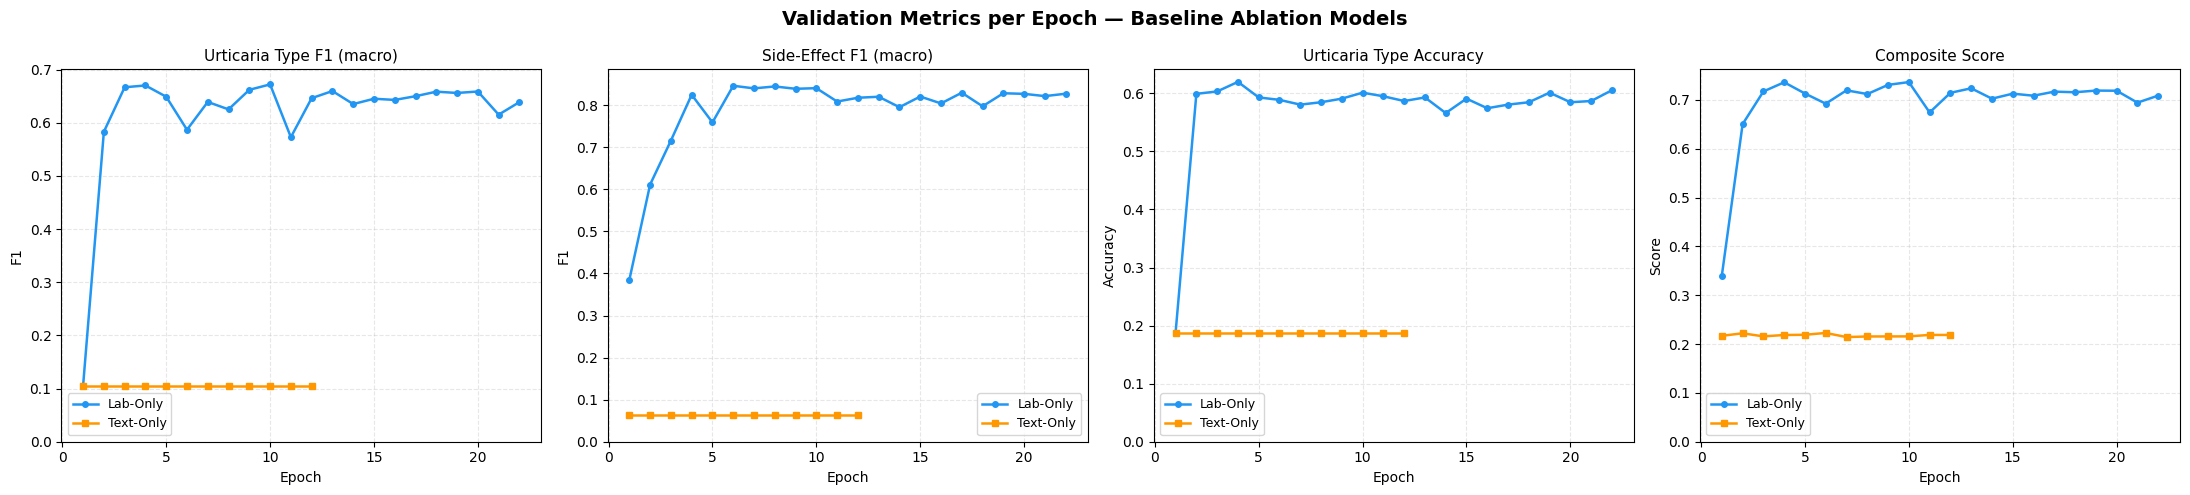

Saved: ablation_training_curves.png


In [16]:
import matplotlib.pyplot as plt
import numpy as np

LAB_COLOR = "#2196F3"
TXT_COLOR = "#FF9800"

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("Validation Metrics per Epoch — Baseline Ablation Models",
             fontsize=14, fontweight="bold")

def plot_metric(ax, key, title, ylabel=""):
    el = [r["epoch"] for r in lab_history]
    et = [r["epoch"] for r in txt_history]
    ax.plot(el, [r[key] for r in lab_history],
            color=LAB_COLOR, marker="o", markersize=4, lw=1.8, label="Lab-Only")
    ax.plot(et, [r[key] for r in txt_history],
            color=TXT_COLOR, marker="s", markersize=4, lw=1.8, label="Text-Only")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Epoch")
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.set_ylim(bottom=0)

plot_metric(axes[0], "type_f1_macro", "Urticaria Type F1 (macro)", "F1")
plot_metric(axes[1], "side_f1_macro", "Side-Effect F1 (macro)",    "F1")
plot_metric(axes[2], "type_acc",      "Urticaria Type Accuracy",   "Accuracy")
plot_metric(axes[3], "composite",     "Composite Score",           "Score")

plt.tight_layout()
plt.savefig("ablation_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ablation_training_curves.png")


## 12) Test Metric Bar Charts — All 3 Models
> Paste Gated Fusion test results into `GATED_FUSION_METRICS` (Cell 10) before running this cell.

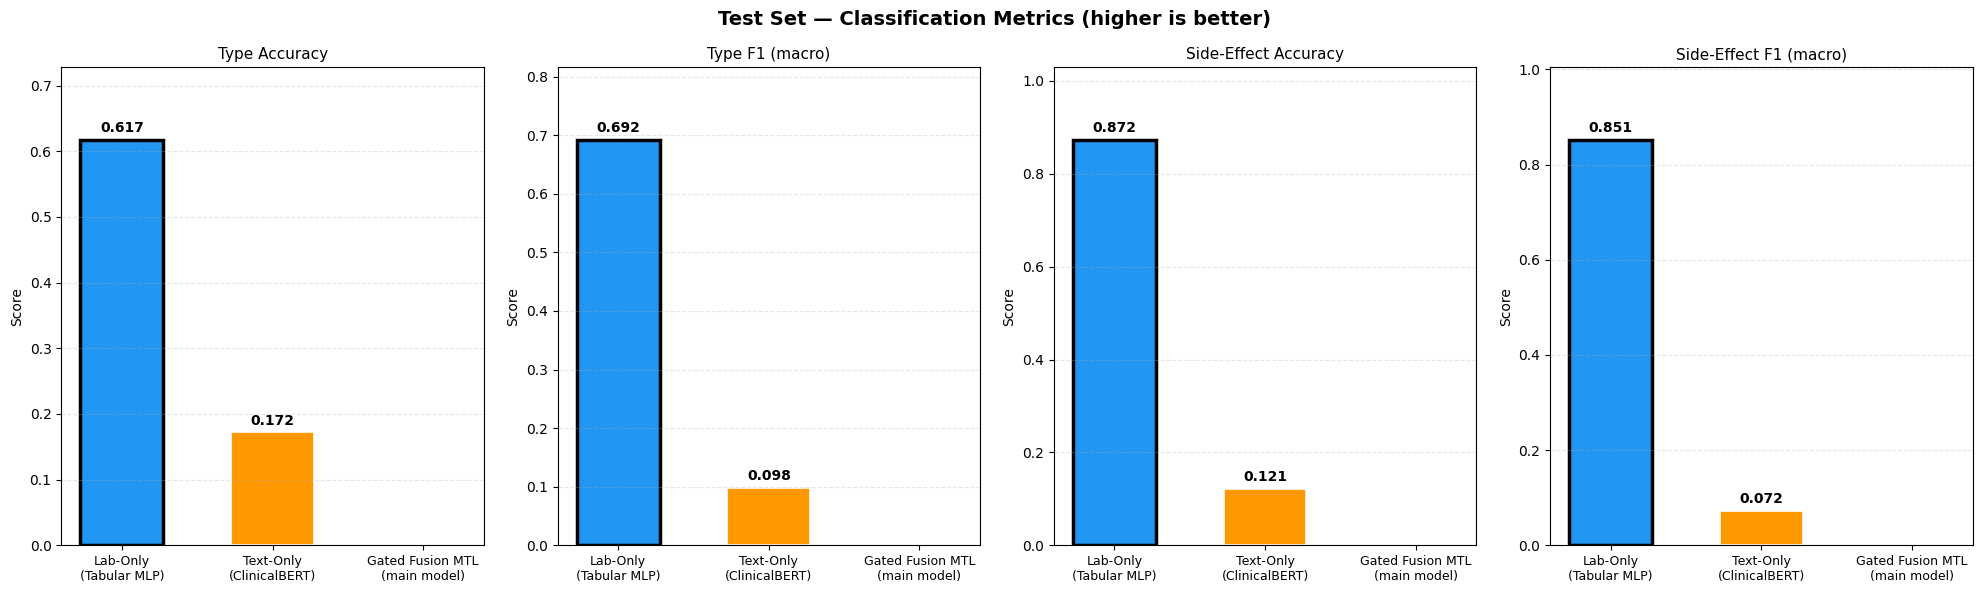

Saved: ablation_clf_bar_chart.png


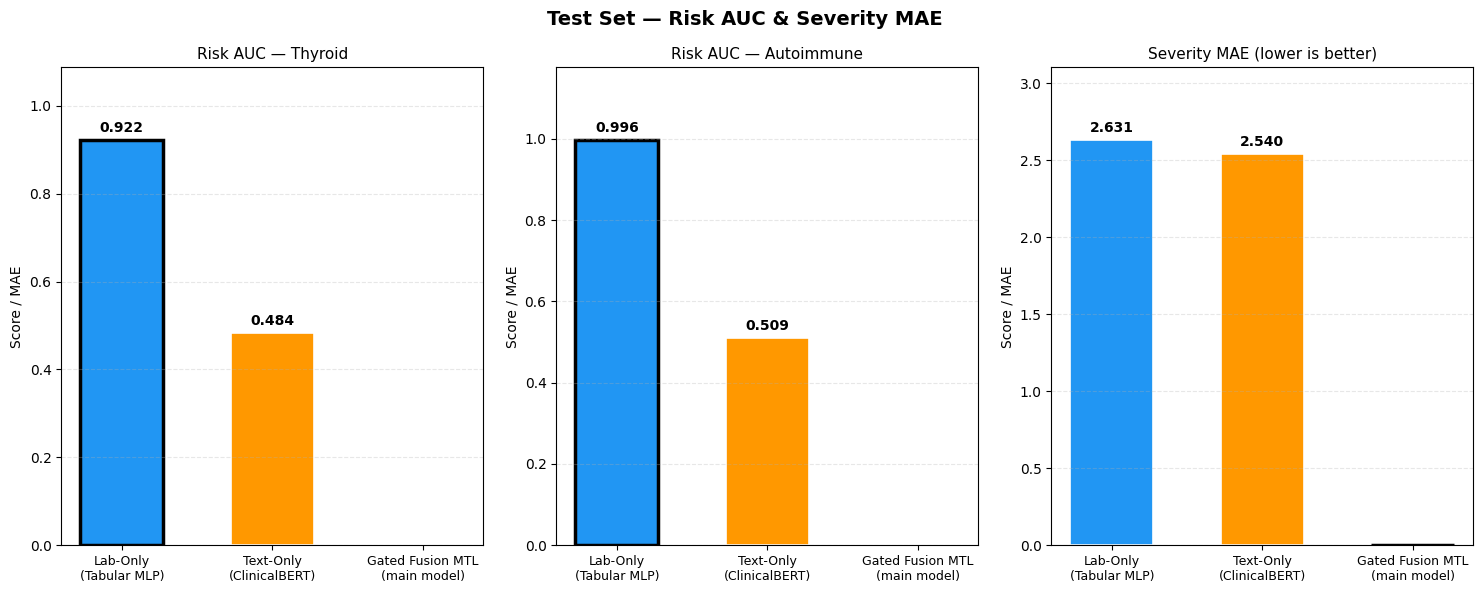

Saved: ablation_risk_bar_chart.png


In [17]:
import matplotlib.pyplot as plt
import numpy as np

model_names = ["Lab-Only\n(Tabular MLP)", "Text-Only\n(ClinicalBERT)", "Gated Fusion MTL\n(main model)"]
colors      = ["#2196F3", "#FF9800", "#4CAF50"]
all_results = [lab_test_metrics, txt_test_metrics, GATED_FUSION_METRICS]

def draw_bar_group(fig_title, metric_list, ylabel, save_name, lower_key=None):
    n = len(metric_list)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 6))
    fig.suptitle(fig_title, fontsize=14, fontweight="bold")
    if n == 1:
        axes = [axes]
    for ax, (key, label) in zip(axes, metric_list):
        vals = [m[key] if m[key] is not None else 0 for m in all_results]
        bars = ax.bar(model_names, vals, color=colors, edgecolor="white", lw=1.2, width=0.55)
        vmax = max(vals) if any(vals) else 1.0
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + vmax * 0.012,
                        f"{v:.3f}", ha="center", va="bottom",
                        fontsize=10, fontweight="bold")
        ax.set_title(label, fontsize=11)
        ax.set_ylim(0, vmax * 1.18 if vmax else 1.2)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", labelsize=9)
        ax.grid(axis="y", alpha=0.3, linestyle="--")
        # Highlight best bar with black border
        best = int(np.argmin(vals) if key == lower_key else np.argmax(vals))
        bars[best].set_edgecolor("black")
        bars[best].set_linewidth(2.5)
    plt.tight_layout()
    plt.savefig(save_name, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved:", save_name)

# --- Chart A: Classification ---
draw_bar_group(
    "Test Set — Classification Metrics (higher is better)",
    [("type_acc",      "Type Accuracy"),
     ("type_f1_macro", "Type F1 (macro)"),
     ("side_acc",      "Side-Effect Accuracy"),
     ("side_f1_macro", "Side-Effect F1 (macro)")],
    "Score",
    "ablation_clf_bar_chart.png"
)

# --- Chart B: Risk AUC + Severity ---
draw_bar_group(
    "Test Set — Risk AUC & Severity MAE",
    [("risk_auc_thyroid",    "Risk AUC — Thyroid"),
     ("risk_auc_autoimmune", "Risk AUC — Autoimmune"),
     ("severity_mae",        "Severity MAE (lower is better)")],
    "Score / MAE",
    "ablation_risk_bar_chart.png",
    lower_key="severity_mae"
)


## 13) Radar (Spider) Chart — Full Model Profile

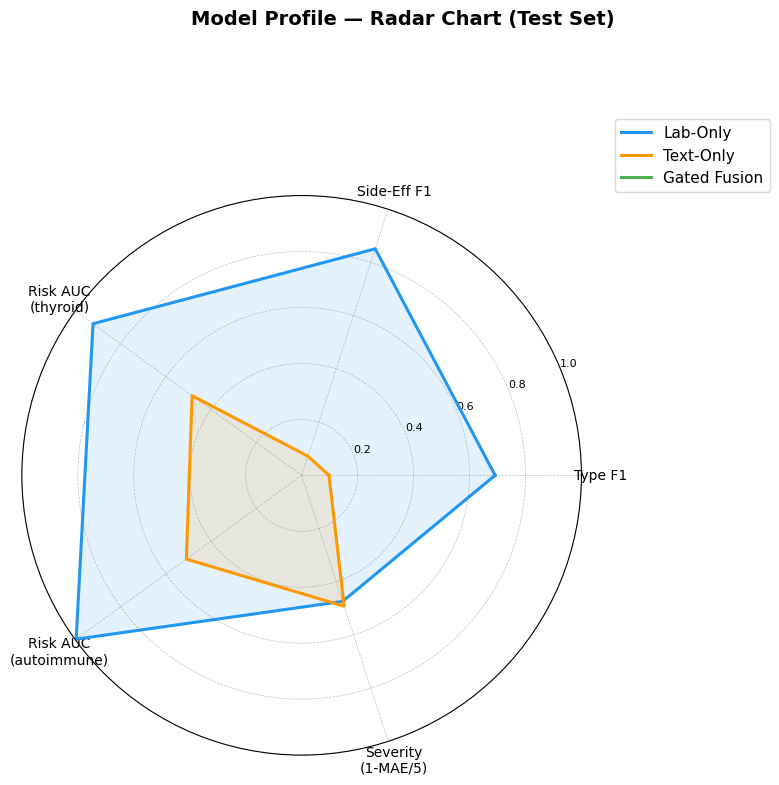

Saved: ablation_radar_chart.png


In [18]:
import matplotlib.pyplot as plt
import numpy as np

radar_labels = ["Type F1", "Side-Eff F1",
                "Risk AUC\n(thyroid)", "Risk AUC\n(autoimmune)", "Severity\n(1-MAE/5)"]

def to_radar_vals(m):
    sev = max(0.0, 1.0 - (m["severity_mae"] or 5.0) / 5.0)
    return [m["type_f1_macro"]       or 0,
            m["side_f1_macro"]       or 0,
            m["risk_auc_thyroid"]    or 0,
            m["risk_auc_autoimmune"] or 0,
            sev]

model_names_r = ["Lab-Only", "Text-Only", "Gated Fusion"]
colors_r      = ["#2196F3", "#FF9800", "#4CAF50"]
all_vals      = [to_radar_vals(m) for m in all_results]

N      = len(radar_labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})
fig.suptitle("Model Profile — Radar Chart (Test Set)",
             fontsize=14, fontweight="bold", y=1.02)

for vals, name, color in zip(all_vals, model_names_r, colors_r):
    closed = vals + vals[:1]
    ax.plot(angles, closed, color=color, linewidth=2.2, label=name)
    ax.fill(angles, closed, color=color, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8)
ax.grid(color="grey", linestyle="--", lw=0.5, alpha=0.5)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=11)

plt.tight_layout()
plt.savefig("ablation_radar_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ablation_radar_chart.png")


## 14) Accuracy Improvement Delta — Gated Fusion vs Baselines
> Shows how much the Gated Fusion MTL model improves over each baseline for each metric. Positive = fusion wins, negative = baseline wins.

In [19]:
import matplotlib.pyplot as plt
import numpy as np

if GATED_FUSION_METRICS["type_f1_macro"] is None:
    print("Paste Gated Fusion metrics into GATED_FUSION_METRICS (Cell 10) first.")
else:
    delta_m = [
        ("type_acc",            "Type\nAccuracy"),
        ("type_f1_macro",       "Type\nF1 (macro)"),
        ("side_acc",            "Side-Eff\nAccuracy"),
        ("side_f1_macro",       "Side-Eff\nF1 (macro)"),
        ("risk_auc_thyroid",    "Risk AUC\nThyroid"),
        ("risk_auc_autoimmune", "Risk AUC\nAutoimmune"),
    ]
    fused   = GATED_FUSION_METRICS
    x       = np.arange(len(delta_m))
    width   = 0.35
    gap_lab = [(fused[k] or 0) - (lab_test_metrics[k] or 0) for k, _ in delta_m]
    gap_txt = [(fused[k] or 0) - (txt_test_metrics[k] or 0) for k, _ in delta_m]
    labels  = [lbl for _, lbl in delta_m]

    fig, ax = plt.subplots(figsize=(14, 6))
    b1 = ax.bar(x - width / 2, gap_lab, width,
                label="Fusion gain over Lab-Only",  color="#2196F3", alpha=0.85)
    b2 = ax.bar(x + width / 2, gap_txt, width,
                label="Fusion gain over Text-Only", color="#FF9800", alpha=0.85)
    ax.axhline(0, color="black", linewidth=1.2)

    for bar in list(b1) + list(b2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + (0.002 if h >= 0 else -0.008),
                f"{h:+.3f}", ha="center",
                va="bottom" if h >= 0 else "top",
                fontsize=9, fontweight="bold",
                color="green" if h > 0 else "red")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_ylabel("Delta Score  (Gated Fusion − Baseline)", fontsize=11)
    ax.set_title("Accuracy Improvement of Gated Fusion MTL over Baselines  [Test Set]",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.savefig("ablation_improvement_delta.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: ablation_improvement_delta.png")
    print()
    print("Green / positive bars  → Gated Fusion outperforms that baseline.")
    print("Red   / negative bars  → Baseline outperforms Gated Fusion (rare; investigate gate weights).")


Paste Gated Fusion metrics into GATED_FUSION_METRICS (Cell 10) first.
